In [1]:
from starccato_flow.training.trainer_flow_matching_multi import FlowMatchingTrainerMulti
from starccato_flow.data.s_theta import sTheta
from starccato_flow.utils.defaults import TEN_KPC

MPS device found


/Users/tarineccleston/Desktop/starccato/starccato-flow/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Configs

In [2]:
font_family = "serif"
font_name = "Times New Roman"

In [3]:
data_all = sTheta(
            num_epochs=1,
            detector_noise_on=False,
            parameters=["beta1_IC_b", "omega_0(rad|s)", "A(km)", "Ye_c_b"])


sTheta Dataset - Parameter Bounds (4 parameters)
beta1_IC_b          : [    0.000354,     0.215477]
omega_0(rad|s)      : [    0.500000,    15.500000]
A(km)               : [  300.000000, 10000.000000]
Ye_c_b              : [    0.246499,     0.282820]



### Signal Distribution Plot

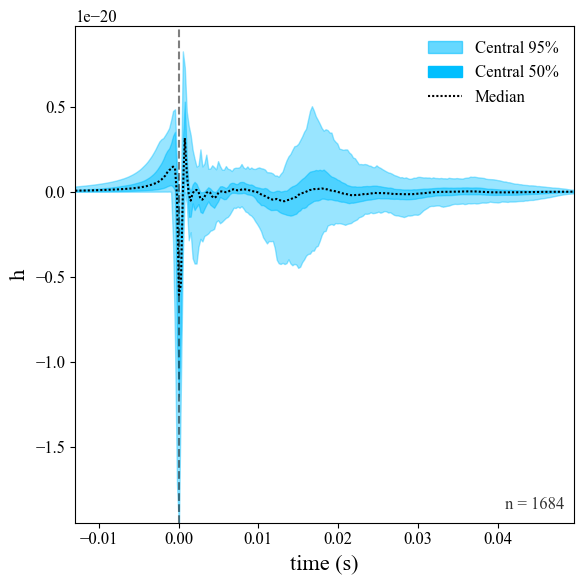

In [4]:
data_all.plot_signal_distribution(
    fname="../../2025-Statistics-Masters-Thesis/figures/eda/signal_distribution.png",
    background="white",
    font_family=font_family,
    font_name=font_name
)

### Parameter Distribution Plots

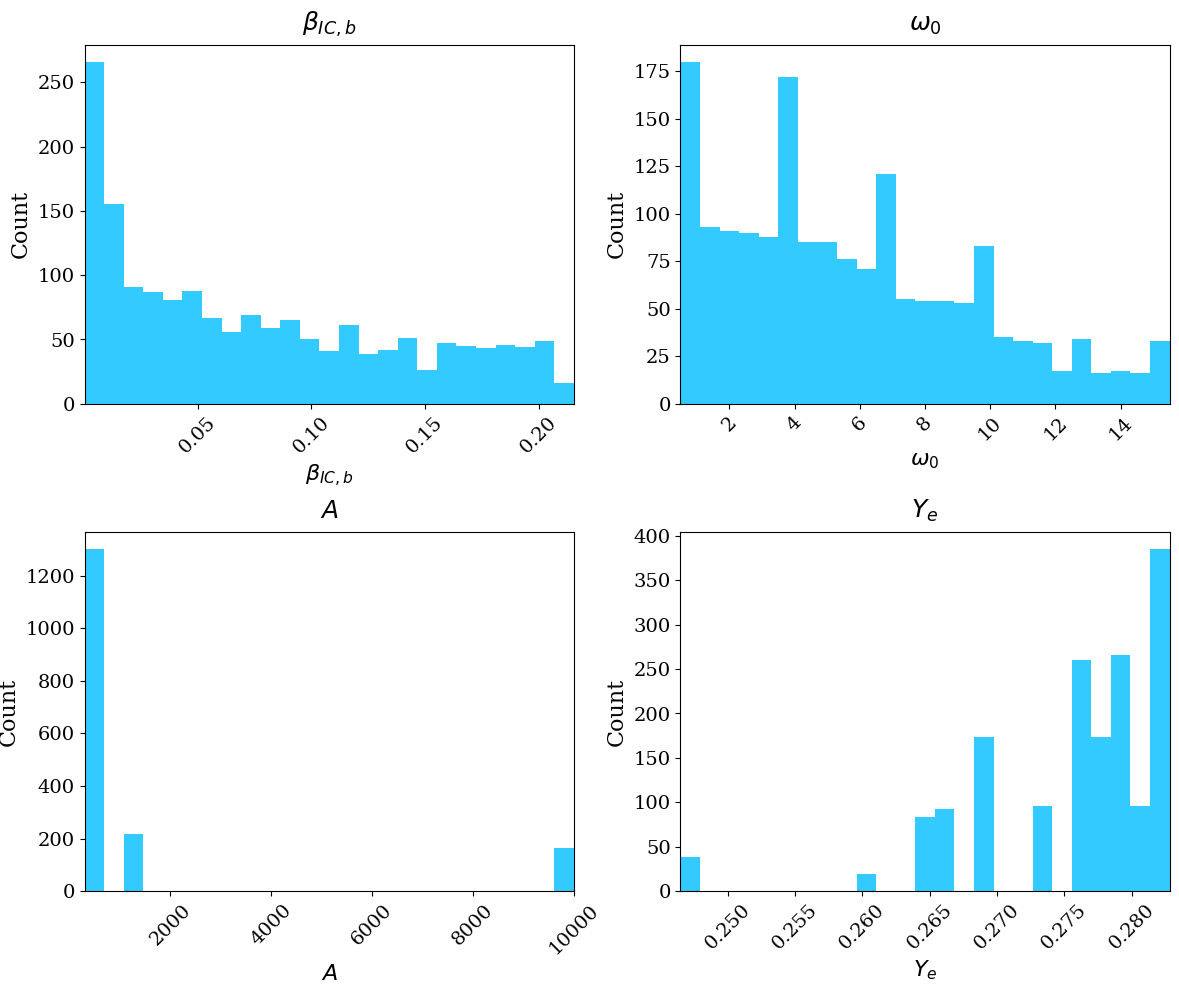

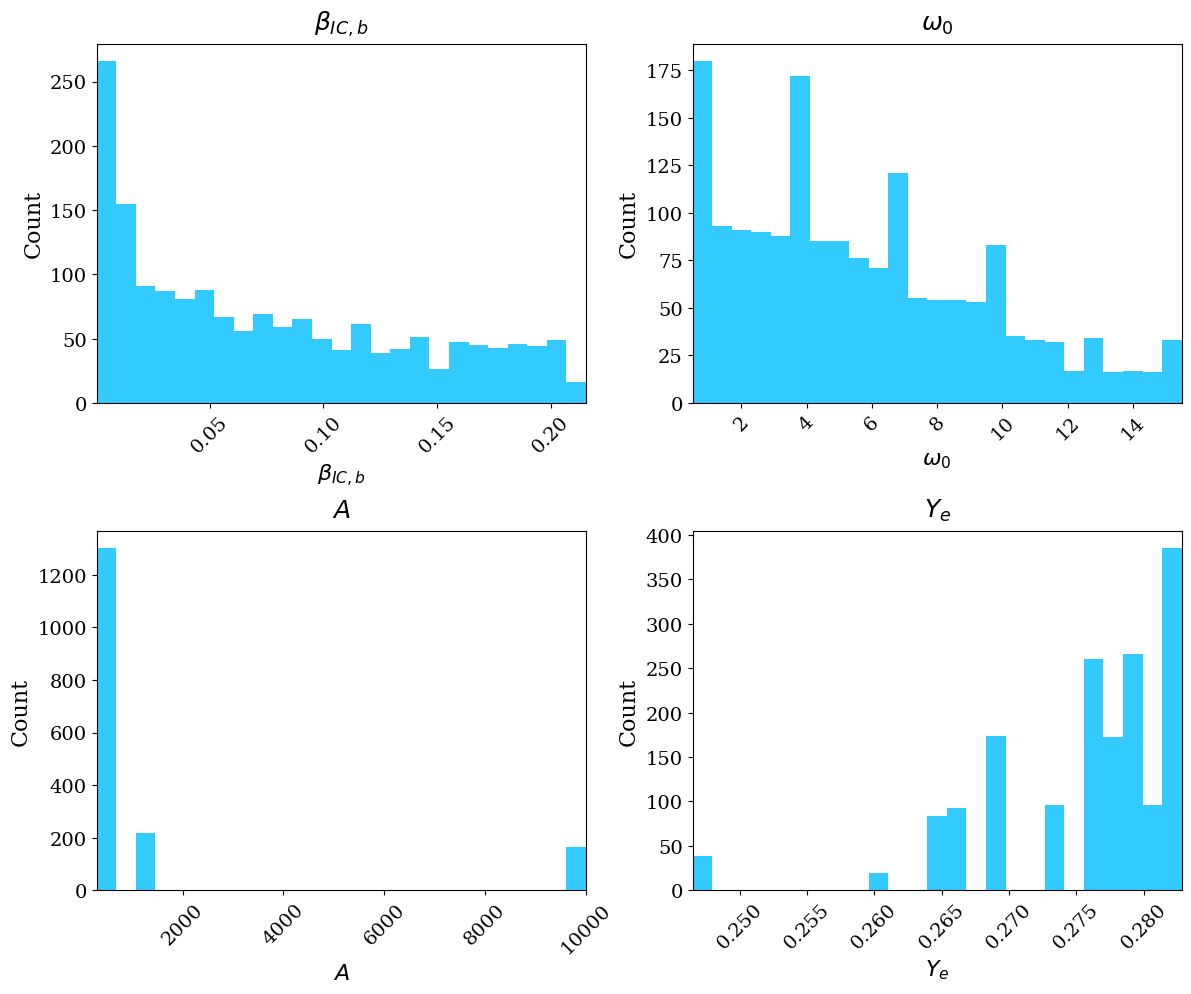

In [5]:
from starccato_flow.plotting.parameters import plot_parameter_distribution_grid

params_dict = {
    param: data_all.parameters[:, data_all.parameter_names.index(param)] 
    for param in data_all.parameter_names
}

plot_parameter_distribution_grid(
    parameters_dict=params_dict,
    fname="../../2025-Statistics-Masters-Thesis/figures/eda/parameter_distribution_grid.png",
    font_family=font_family,
    font_name=font_name
)

### Signal Grid Plot (4x2)

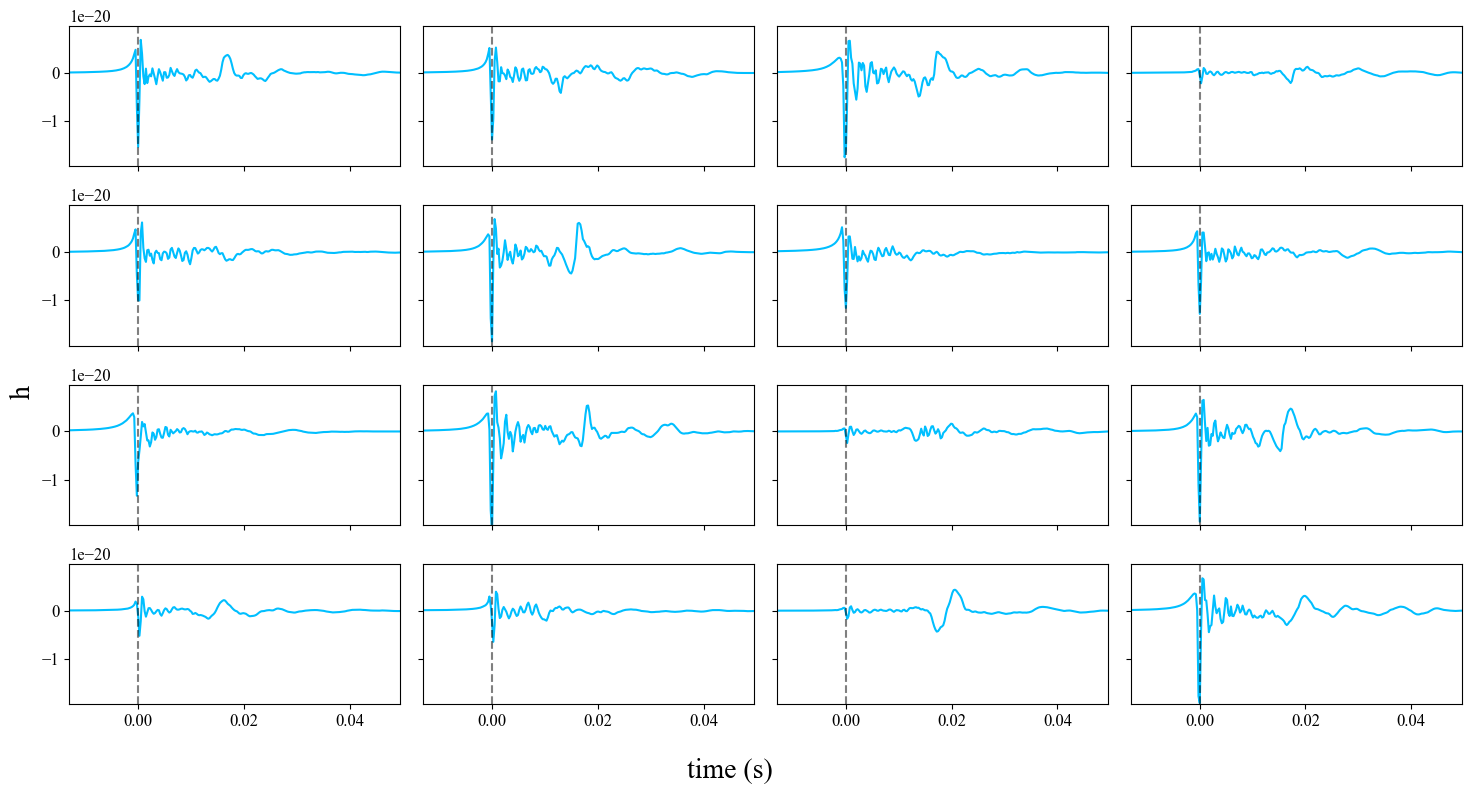

In [6]:
from starccato_flow.plotting.signals import plot_signal_grid
import numpy as np

# Collect 16 random signals (4 x 2 grid)
n_signals = 16
np.random.seed(42)
random_indices = np.random.choice(len(data_all), size=n_signals, replace=False)
selected_signals = []
for idx in random_indices:
    signal = data_all[idx][1].cpu().numpy().flatten()
    selected_signals.append(signal)

selected_signals = np.array(selected_signals)

# Plot in 4x4 grid
plot_signal_grid(
    signals=selected_signals / TEN_KPC,  # TEN_KPC normalization
    noisy_signals=None,
    max_value=data_all.shared_max_strain,
    num_cols=4,
    num_rows=4,
    fname="../../2025-Statistics-Masters-Thesis/figures/eda/signal_grid_4x4.png",
    generated=False,
    background="white",
    font_family=font_family,
    font_name=font_name
);

### Erroneous Signals Grid (beta < 0)


sTheta Dataset - Parameter Bounds (4 parameters)
beta1_IC_b          : [   -1.000000,     0.215477]
omega_0(rad|s)      : [    0.000000,    15.500000]
A(km)               : [  300.000000, 10000.000000]
Ye_c_b              : [   -1.000000,     0.282820]

Found 80 erroneous signals with beta < 0


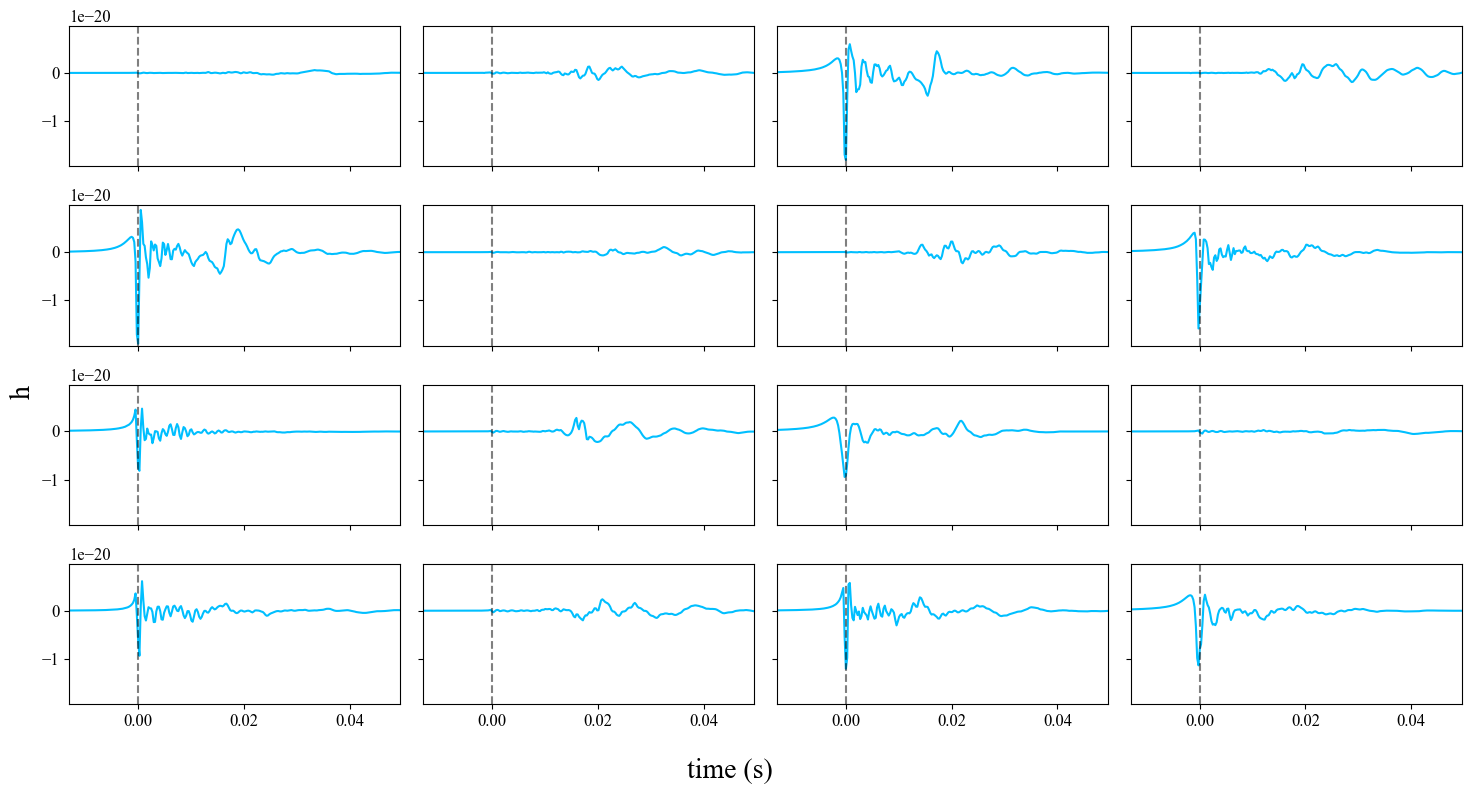

In [7]:
# Load all data including erroneous signals (beta < 0)
data_all_with_errors = sTheta(
    num_epochs=1,
    detector_noise_on=False,
    parameters=["beta1_IC_b", "omega_0(rad|s)", "A(km)", "Ye_c_b"],
    remove_erroneous=False
)

# Find signals with erroneous beta < 0
beta_idx = data_all_with_errors.parameter_names.index("beta1_IC_b")
erroneous_mask = data_all_with_errors.parameters[:, beta_idx] <= 0
erroneous_indices = np.where(erroneous_mask)[0]

print(f"Found {len(erroneous_indices)} erroneous signals with beta < 0")

if len(erroneous_indices) >= 16:
    # Collect 16 random erroneous signals
    np.random.seed(42)
    selected_erroneous_idx = np.random.choice(erroneous_indices, size=16, replace=False)
    erroneous_signals = []
    for idx in selected_erroneous_idx:
        signal = data_all_with_errors[idx][1].cpu().numpy().flatten()
        erroneous_signals.append(signal)
    
    erroneous_signals = np.array(erroneous_signals)
    
    plot_signal_grid(
        signals=erroneous_signals / TEN_KPC,
        noisy_signals=None,
        max_value=data_all_with_errors.shared_max_strain,
        num_cols=4,
        num_rows=4,
        fname="../../2025-Statistics-Masters-Thesis/figures/eda/erroneous_signal_grid_4x4.png",
        generated=False,
        background="white",
        font_family=font_family,
        font_name=font_name
    );
else:
    print(f"Not enough erroneous signals ({len(erroneous_indices)}) to make a 4x2 grid!")

### EOS and Electron Fraction

EOS: BHBL, Ye_c_b mean: 0.2797, std: 0.0000, count: 74
EOS: BHBLP, Ye_c_b mean: 0.2796, std: 0.0000, count: 96
EOS: GShenFSU1.7, Ye_c_b mean: 0.2758, std: 0.0000, count: 78
EOS: GShenFSU2.1, Ye_c_b mean: 0.2758, std: 0.0000, count: 86
EOS: GShenNL3, Ye_c_b mean: 0.2688, std: 0.0000, count: 81
EOS: HSDD2, Ye_c_b mean: 0.2795, std: 0.0000, count: 96
EOS: HSFSG, Ye_c_b mean: 0.2813, std: 0.0000, count: 96
EOS: HSIUF, Ye_c_b mean: 0.2817, std: 0.0000, count: 96
EOS: HSNL3, Ye_c_b mean: 0.2765, std: 0.0000, count: 96
EOS: HSTM1, Ye_c_b mean: 0.2775, std: 0.0000, count: 83
EOS: HSTMA, Ye_c_b mean: 0.2740, std: 0.0000, count: 96
EOS: HShen, Ye_c_b mean: 0.2827, std: 0.0000, count: 96
EOS: HShenH, Ye_c_b mean: 0.2828, std: 0.0000, count: 97
EOS: LS180, Ye_c_b mean: 0.2647, std: 0.0000, count: 84
EOS: LS220, Ye_c_b mean: 0.2662, std: 0.0000, count: 93
EOS: LS375, Ye_c_b mean: 0.2692, std: 0.0000, count: 93
EOS: SFHo, Ye_c_b mean: 0.2779, std: 0.0000, count: 90
EOS: SFHo_ecapture_0.1, Ye_c_b mea

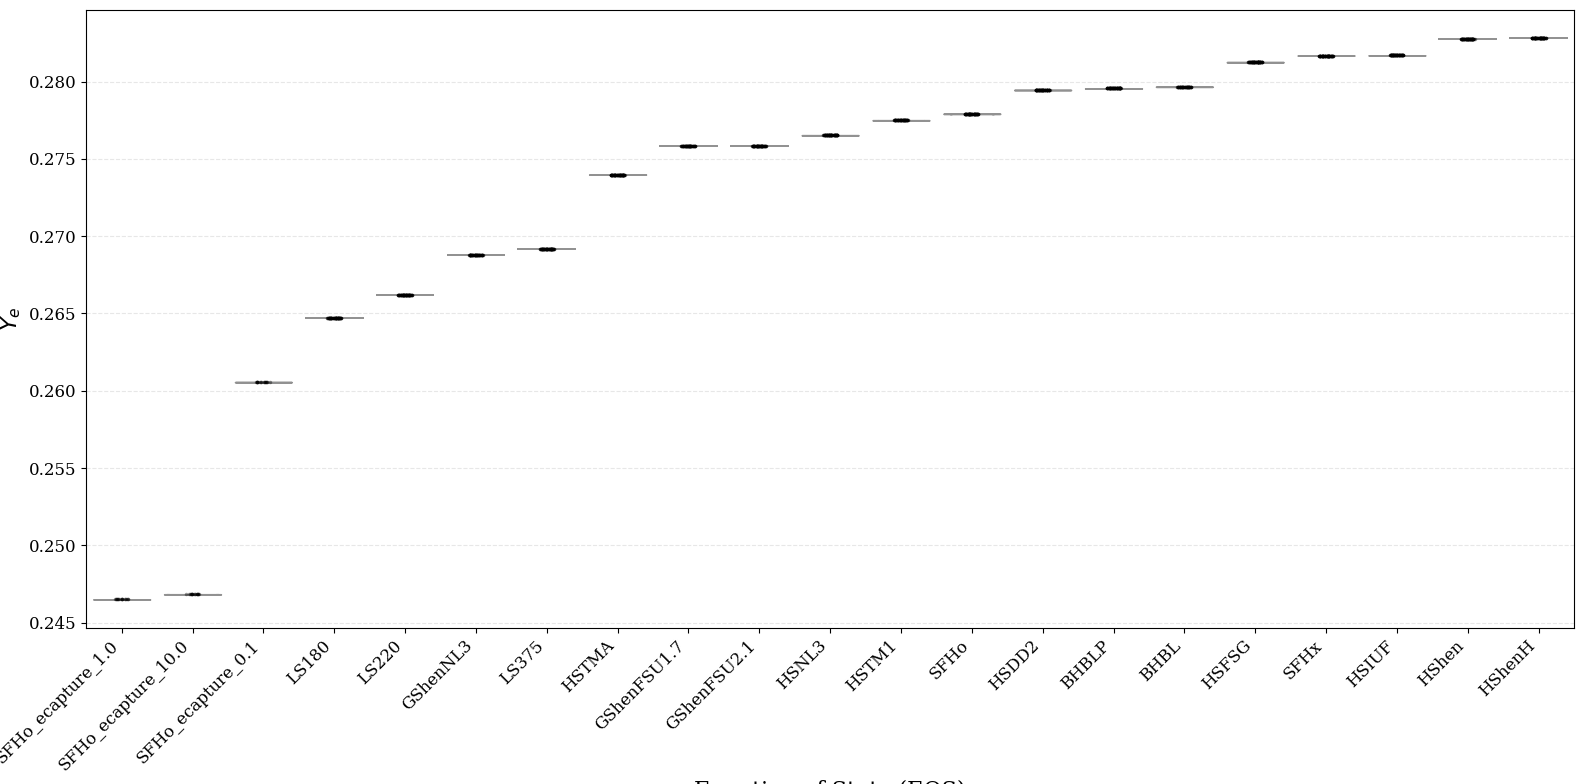

In [ ]:
from starccato_flow.plotting.parameters import plot_eos_ye_distribution

plot_eos_ye_distribution(
    eos_values=data_all.eos,
    ye_values=data_all.parameters[:, data_all.parameter_names.index("Ye_c_b")],
    fname="../../2025-Statistics-Masters-Thesis/figures/eda/eos_ye_distribution.png",
    background="white",
    font_family=font_family,
    font_name=font_name,
    jitter_strength=0.15,
    alpha=0.6,
    point_size=50

### Add, Commit, Push

In [9]:
import subprocess

# Add all files
subprocess.run(["git", "pull"], cwd="../../2025-Statistics-Masters-Thesis")
subprocess.run(["git", "add", "."], cwd="../../2025-Statistics-Masters-Thesis")
# Commit
subprocess.run(["git", "commit", "-m", "Update Plots"], cwd="../../2025-Statistics-Masters-Thesis")
# Push
subprocess.run(["git", "push"], cwd="../../2025-Statistics-Masters-Thesis")

Already up to date.
[main 8f27fcf] Update Plots
 1 file changed, 0 insertions(+), 0 deletions(-)


To github.com:the-tarin/2025-Statistics-Masters-Thesis.git
   94048b5..8f27fcf  main -> main


CompletedProcess(args=['git', 'push'], returncode=0)